# Sequential CTTA: Messidor → IDRiD → APTOS (VisionFM)

Protocol:
1. Load VisionFM pretrained weights
2. Evaluate baseline on source domain (Messidor-2)
3. Adapt to target domain (IDRiD) - adaptation mode
4. Adapt to target domain (APTOS) - adaptation mode
5. Evaluate on ALL previous domains - TEST mode

This tests if Messidor as source provides useful initialization.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/sequential/cotta/messidor_idrid_aptos_visionfm.yaml')

print('Protocol: Sequential CTTA')
print(f'Source: {config.sequential.source_dataset.name}')
print(f'Targets: {[t.name for t in config.sequential.target_datasets]}')
print('Method:', config.ctta.method)
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Protocol: Sequential CTTA
Source: messidor2
Targets: ['idrid', 'aptos2019']
Method: cotta
Output: ./outputs/sequential_cotta/messidor_idrid_aptos_visionfm/
No HF token needed (VisionFM / Google Drive)


In [4]:
from src.evaluation.runner import SequentialCTTARunner

runner = SequentialCTTARunner(config)
results = runner.run()

2026-08-05 16:53:29,011 - src.evaluation.runner.sequential - INFO - Starting sequential CTTA: messidor2 -> idrid -> aptos2019
2026-08-05 16:53:29,013 - src.models.visionfm_download - INFO - VisionFM Fundus weights found at ./cache/visionfm/VFM_Fundus_weights.pth (cached)
2026-08-05 16:53:30,275 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-08-05 16:53:31,309 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-08-05 16:53:31,310 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-08-05 16:53:31,383 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-08-05 16:53:31,424 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-08-05 16:53:31,425 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-08-05 16:53:31,803 - src.evaluation.runner.base - INFO - Loaded RETFound pretra

Adapting to messidor2:   0%|          | 0/22 [00:00<?, ?it/s]

2026-08-05 16:54:03,757 - src.evaluation.runner.sequential - INFO -   Adapt step 0: loss=0.1634, kl=0.1324, conf_samples=8, teacher_max_prob=0.7287


Adapting to messidor2:   5%|▍         | 1/22 [00:03<01:04,  3.09s/it, acc=0.3750, adaptations=1]

2026-08-05 16:54:06,094 - src.evaluation.runner.sequential - INFO -   Adapt step 1: loss=0.1219, kl=0.0871, conf_samples=6, teacher_max_prob=0.6894


...

Adapting to aptos2019:  96%|█████████▌| 22/23 [01:22<00:03,  3.52s/it, acc=0.2500, adaptations=22]

2026-08-05 16:57:13,357 - src.evaluation.runner.sequential - INFO -   Adapt step 22: loss=0.0225, kl=0.1007, conf_samples=7, teacher_max_prob=0.6488


Adapting to aptos2019: 100%|██████████| 23/23 [01:25<00:00,  3.71s/it, acc=0.2143, adaptations=23]

2026-08-05 16:57:13,537 - src.evaluation.runner.sequential - INFO - Evaluating after adaptation on aptos2019


2026-08-05 16:57:31,535 - src.evaluation.runner.sequential - INFO - Post-adaptation QWK: 0.4404
2026-08-05 16:57:31,538 - src.evaluation.runner.sequential - INFO - Adaptations: 23/23
2026-08-05 16:57:31,651 - src.evaluation.runner.sequential - INFO - 
Evaluating on all 3 seen domains after adapting to aptos2019
2026-08-05 16:57:31,652 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on messidor2 (no adaptation)
2026-08-05 16:57:37,075 - src.evaluation.runner.sequential - INFO -   QWK on messidor2: 0.5449
2026-08-05 16:57:37,077 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on idrid (no adaptation)
2026-08-05 16:57:43,276 - src.evaluation.runner.sequential - INFO -   QWK on idrid: 0.3506
2026-08-05 16:58:01,523 - src.evaluation.runner.sequential - INFO -   QWK on aptos2019: 0.4404
2026-08-05 16:58:01,525 - src.evaluation.runner.sequential - INFO - 
2026-08-05 16:58:01,526 - src.evaluation.runner.sequential - INFO - Sequential CTTA Complete - Summar

============== Sequential CTTA Results (CoTTA VisionFM) ==============

Source domain: messidor2
  Baseline QWK:           0.4970
  Baseline Overall Acc:   55.59%

Target domains: idrid, aptos2019

----------------------------------------------------------------------
After adapting to source messidor2 (22/22 batches):
  QWK:                  0.5284  (delta: +0.0314)
  Overall Acc:          56.16% (delta: +0.57pp)

----------------------------------------------------------------------
After adapting to idrid (7/7 batches):
  Post-adaptation QWK on idrid: 0.3815
  Post-adaptation Acc on idrid: 32.04%
  Test on messidor2:
    QWK: 0.5290  (delta vs baseline: +0.0320)
    Acc: 55.87% (delta vs baseline: +0.29pp)

----------------------------------------------------------------------
After adapting to aptos2019 (23/23 batches):
  Post-adaptation QWK on aptos2019: 0.4404
  Post-adaptation Acc on aptos2019: 27.05%
  Test on messidor2:
    QWK: 0.5449  (delta vs baseline: +0.0478)
    Acc: 56

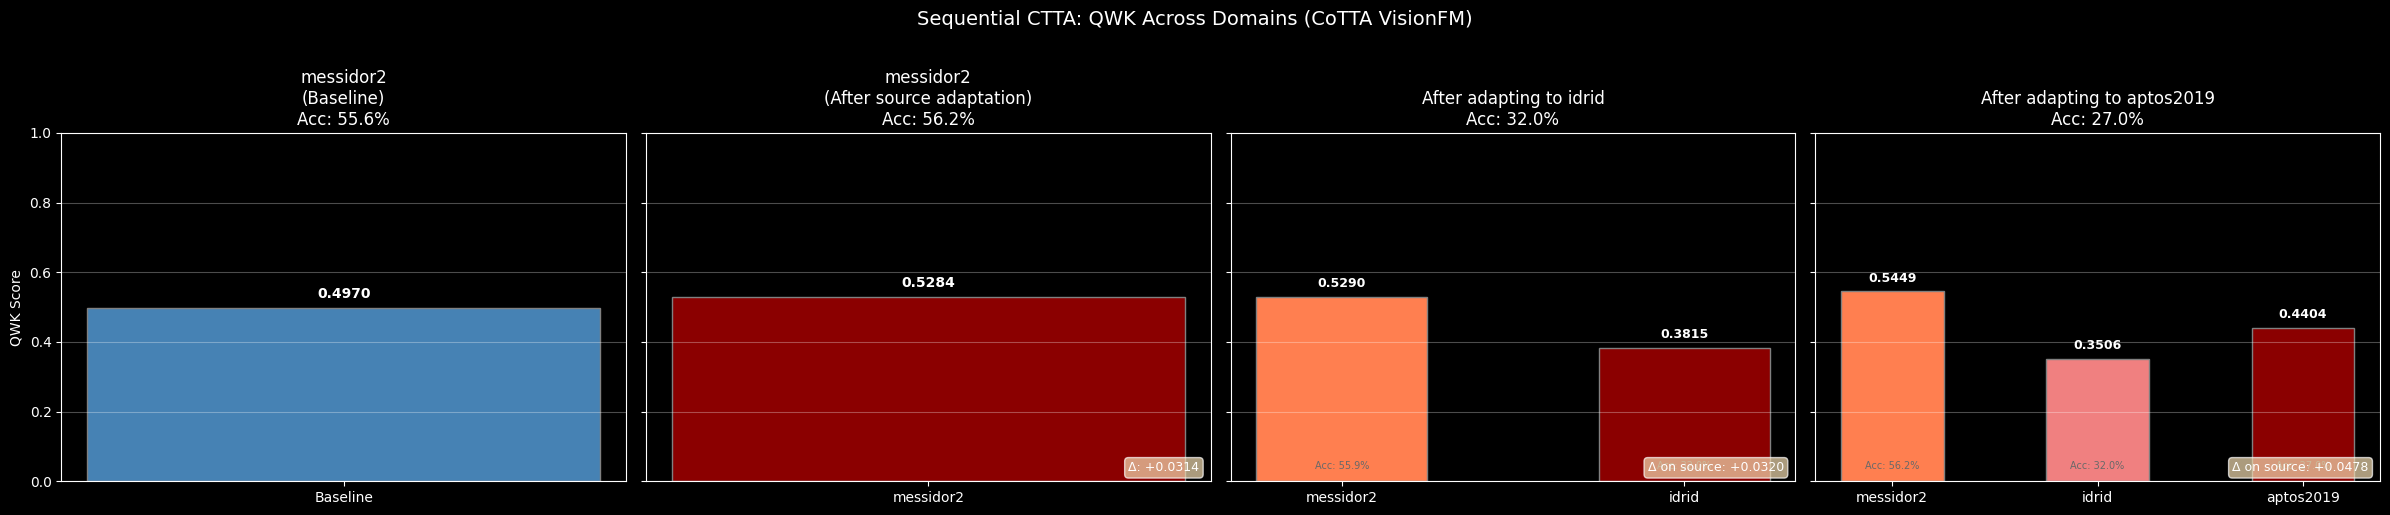

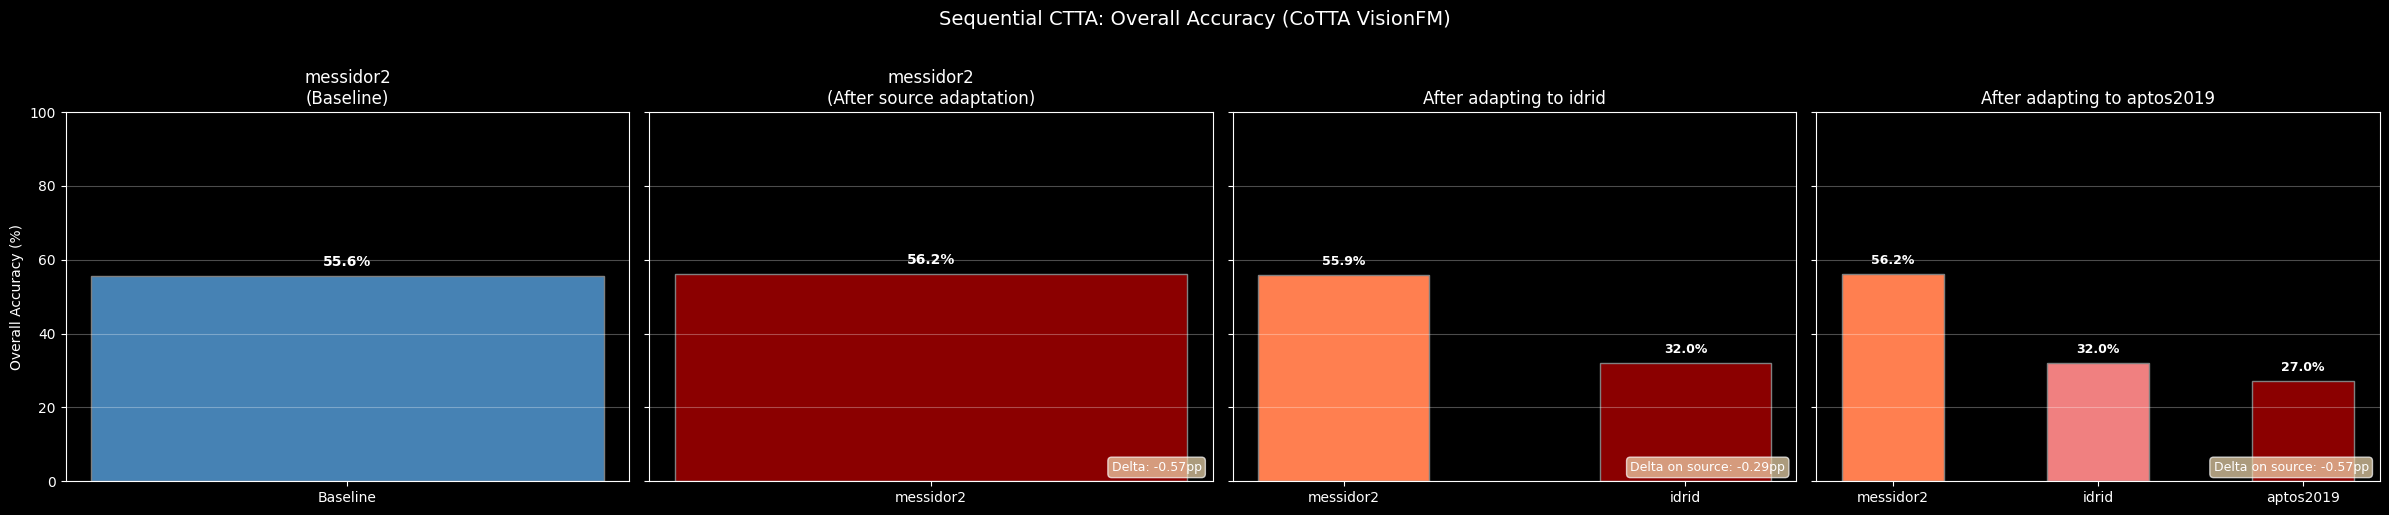

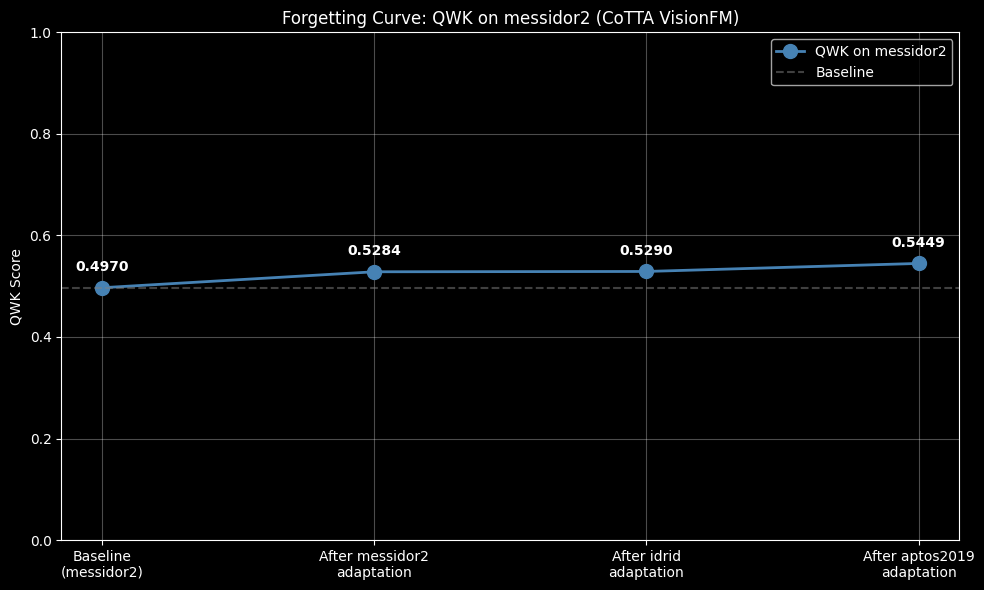

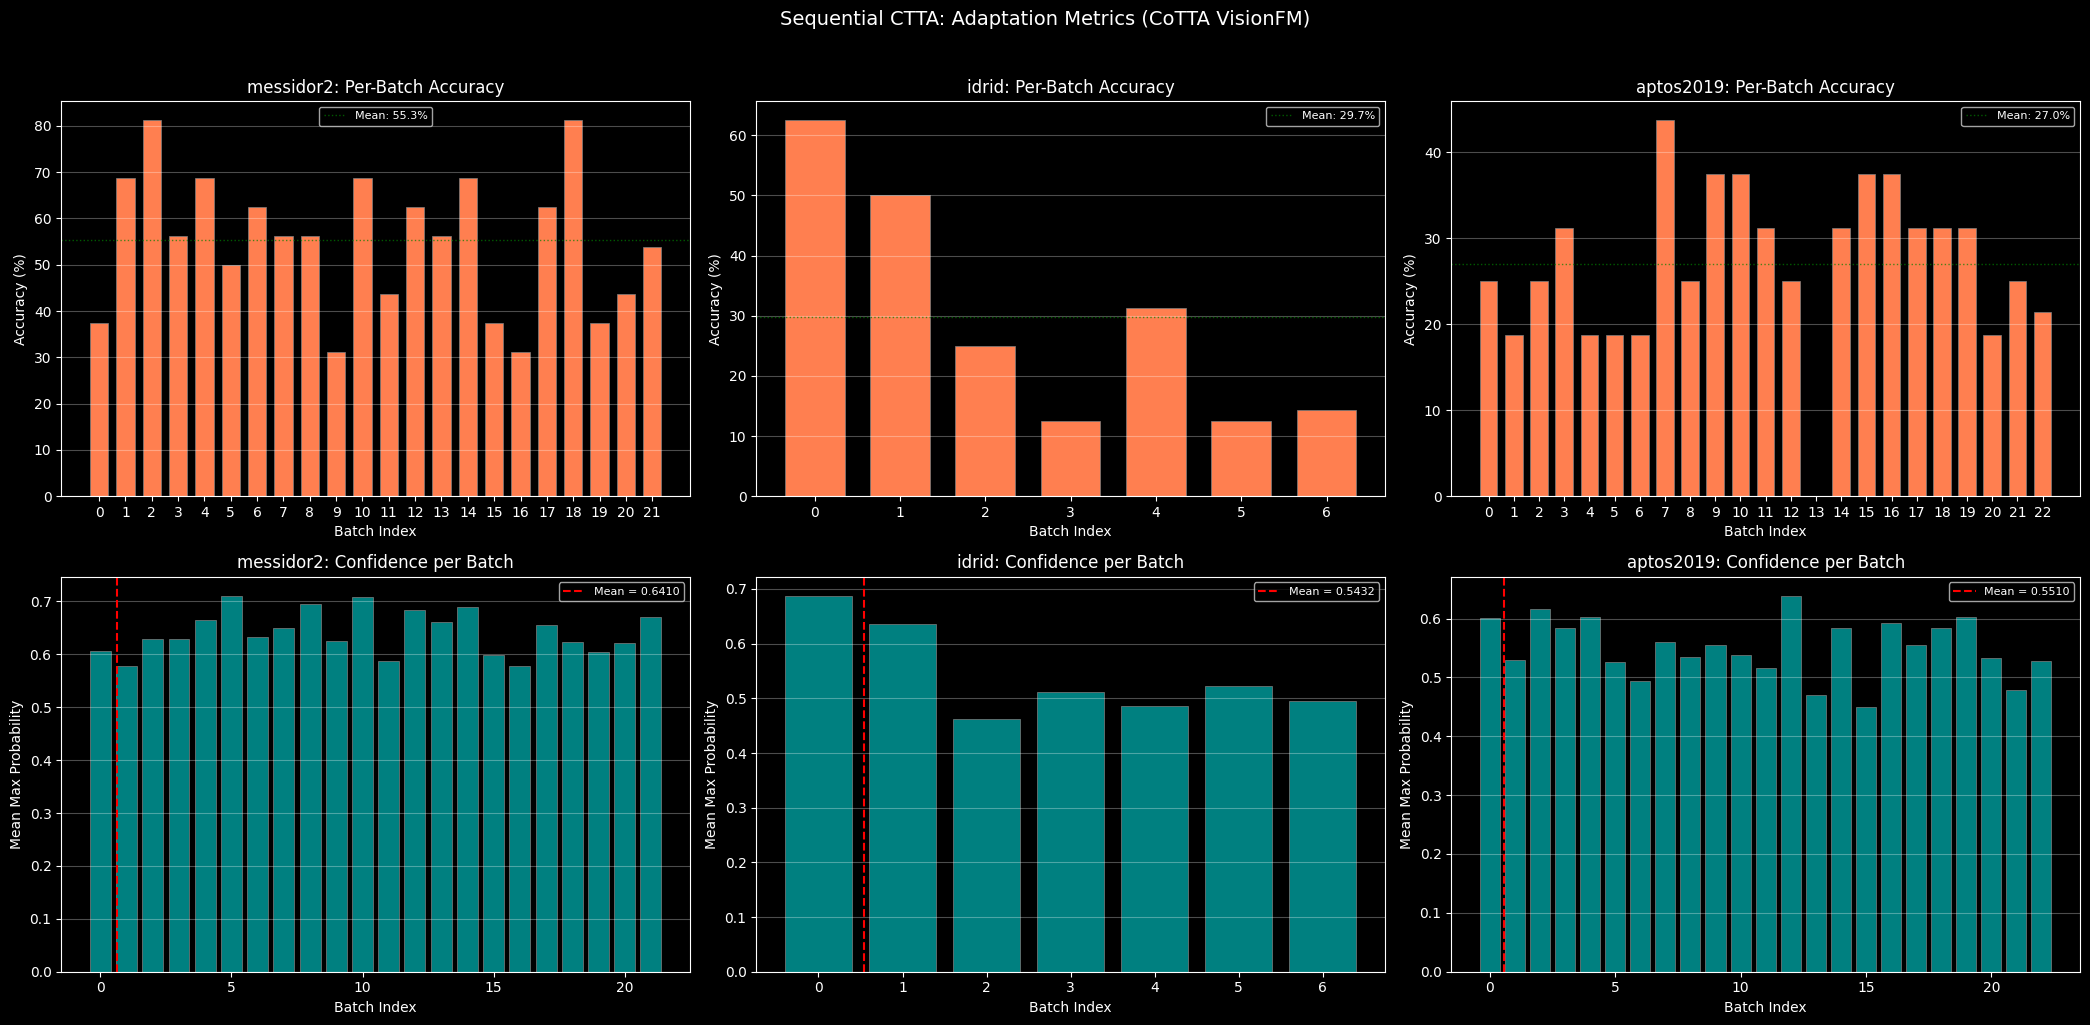

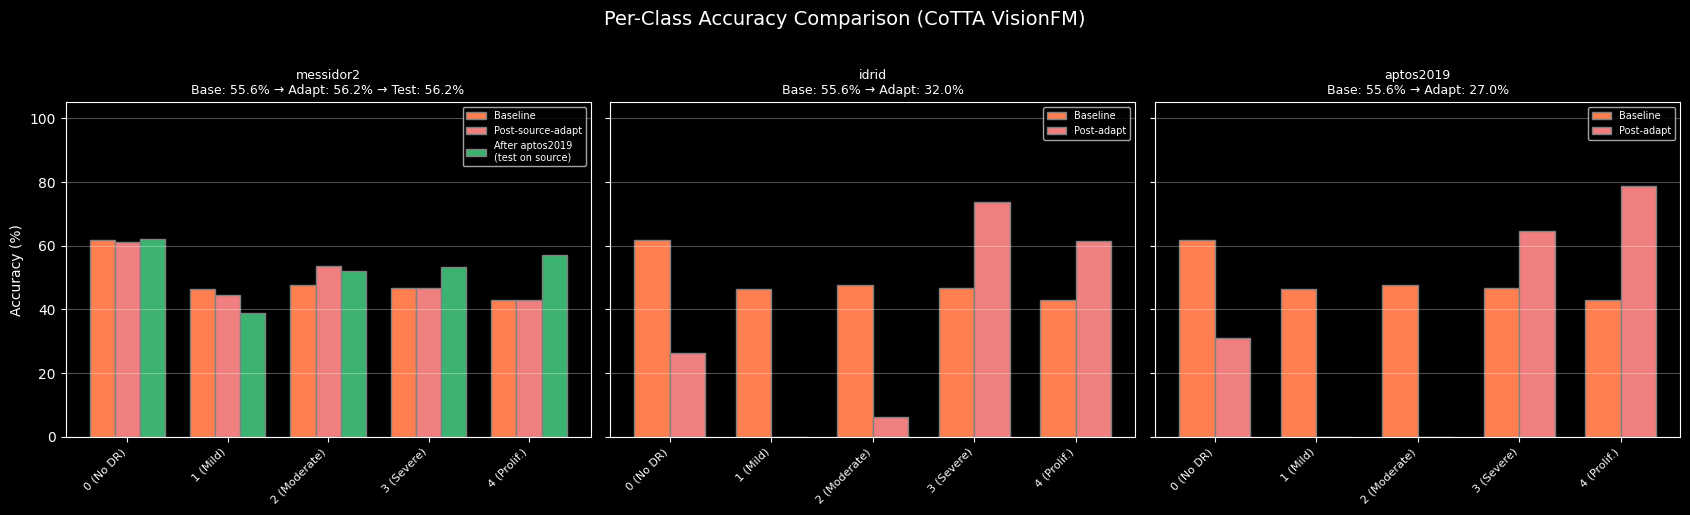

In [5]:
from pathlib import Path
from src.viz import (
    load_standalone_results,
    plot_sequential_qwk_comparison,
    plot_sequential_overall_accuracy,
    plot_sequential_forgetting,
    plot_sequential_adaptation_comparison,
    plot_sequential_per_class_accuracy,
    print_sequential_summary,
)

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

method_name = 'CoTTA DINOv2' if config.model.name == 'retfound' else 'CoTTA VisionFM'

print_sequential_summary(results, method_name=method_name)
plot_sequential_qwk_comparison(results, plots_dir, method_name=method_name)
plot_sequential_overall_accuracy(results, plots_dir, method_name=method_name)
plot_sequential_forgetting(results, plots_dir, method_name=method_name)
plot_sequential_adaptation_comparison(results, plots_dir, method_name=method_name)
plot_sequential_per_class_accuracy(results, plots_dir, method_name=method_name)